# CC5067NT – Smart Data Discovery
## Network Traffic Data Analysis
### 24046034 | Sadikshya Karki | L2C4

---
## Question 1: Data Understanding

In [9]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [10]:
# Loading the dataset
# Reading the CSV file into DataFrame
ds = pd.read_csv('ids.csv')

# Dropping unnecessary index column
ds = ds.drop(columns=["Unnamed: 0"]) 

In [11]:
# Generating summary statistics
ds.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,488115.000000,4.881150e+05,488115.000000,488115.000000,4.881150e+05,4.881150e+05,488115.000000,488115.000000,488115.000000,488115.000000,...,488115.000000,488115.000000,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05,4.881150e+05
mean,8216.354384,8.942263e+06,6.206931,6.185579,5.581399e+02,6.222017e+03,140.936187,17.142253,41.737297,40.785650,...,3.436965,25.697270,6.169126e+04,4.144031e+04,1.325706e+05,3.851845e+04,2.606171e+06,1.184684e+05,2.695488e+06,2.483101e+06
std,17541.650108,2.748091e+07,69.852691,99.359121,2.738195e+04,1.788109e+05,438.404840,31.486744,119.415855,138.185083,...,50.611058,5.851988,5.330001e+05,3.753807e+05,9.292890e+05,4.588439e+05,1.067120e+07,1.614595e+06,1.096955e+07,1.050593e+07
min,0.000000,-2.000000e+00,1.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,53.000000,5.900000e+01,2.000000,1.000000,4.000000e+00,0.000000e+00,2.000000,0.000000,2.000000,0.000000,...,1.000000,20.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,443.000000,3.100000e+02,2.000000,2.000000,4.900000e+01,7.200000e+01,32.000000,2.000000,29.000000,0.000000,...,1.000000,24.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,3221.000000,1.002090e+05,3.000000,2.000000,9.500000e+01,2.460000e+02,51.000000,35.000000,46.000000,0.000000,...,1.000000,32.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65533.000000,1.199999e+08,22673.000000,44553.000000,1.290000e+07,6.360000e+07,23360.000000,2065.000000,4317.097561,4467.113460,...,9130.000000,60.000000,6.520000e+07,3.810000e+07,7.910000e+07,6.520000e+07,1.200000e+08,7.530000e+07,1.200000e+08,1.200000e+08


In [12]:
# Displaying shape 
print(ds.shape)

(488115, 79)


In [13]:
# Viewing dataset info (columns, dtypes, null values)
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 488115 entries, 0 to 488114
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             488115 non-null  int64  
 1   Flow Duration                488115 non-null  int64  
 2   Total Fwd Packets            488115 non-null  int64  
 3   Total Backward Packets       488115 non-null  int64  
 4   Total Length of Fwd Packets  488115 non-null  int64  
 5   Total Length of Bwd Packets  488115 non-null  int64  
 6   Fwd Packet Length Max        488115 non-null  int64  
 7   Fwd Packet Length Min        488115 non-null  int64  
 8   Fwd Packet Length Mean       488115 non-null  float64
 9   Fwd Packet Length Std        488115 non-null  float64
 10  Bwd Packet Length Max        488115 non-null  int64  
 11  Bwd Packet Length Min        488115 non-null  int64  
 12  Bwd Packet Length Mean       488115 non-null  float64
 13 

---
## Question 2: Data Preparation

### 2.1 Load Data and Display Last 50 Records

In [14]:
# Loading dataset from CSV file
df = pd.read_csv('ids.csv')

# Confirming successful load and dataset dimensions
print("Dataset loaded successfully!")
print(f"Total rows: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

# Displaying last 50 records for inspection
print("\nLast 50 Records:")
df.tail(50)

Dataset loaded successfully!
Total rows: 488115
Total columns: 80

Last 50 Records:


,Unnamed: 0,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
488065,488065,53,70591,2,2,66,194,33,33,33.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration
488066,488066,443,5572560,8,6,386,5205,205,0,48.250000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488067,488067,3013,49,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488068,488068,53,122130,2,2,80,272,40,40,40.000000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488069,488069,53,98106274,2,2,114,211,58,56,57.000000,...,20,30943.00000,0.00000,30943,30943,9.800000e+07,0.00000,98000000,98000000,Infiltration
488070,488070,53,506,1,1,53,113,53,53,53.000000,...,32,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488071,488071,53,3957631,2,2,120,260,79,41,60.000000,...,20,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488072,488072,9102,2,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488073,488073,2135,111,2,2,4,12,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,BENIGN
488074,488074,1048,49,2,0,4,0,2,2,2.000000,...,24,0.00000,0.00000,0,0,0.000000e+00,0.00000,0,0,Infiltration


### 2.2 Create a Separate DataFrame with Selected Columns

In [15]:
# Defining required feature columns
columns = [
    'Destination Port', 'Flow Duration', 'Total Fwd Packets',
    'Total Backward Packets', 'Total Length of Fwd Packets',
    'Total Length of Bwd Packets', 'Fwd Packet Length Mean',
    'Bwd Packet Length Mean', 'Flow Bytes/s', 'Flow Packets/s',
    'Packet Length Mean', 'Packet Length Std', 'Average Packet Size',
    'Active Mean', 'Idle Mean', 'Label'
]

# Creating a new DataFrame with only the selected columns
df_selected = df[columns]

# Comparing original and subset shapes
print("Original shape:", df.shape)
print("Subset shape:", df_selected.shape)

# Previewing first 5 rows of subset
print("\nFirst 5 rows:")
df_selected.head()

Original shape: (488115, 80)
Subset shape: (488115, 16)

First 5 rows:


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Mean,Bwd Packet Length Mean,Flow Bytes/s,Flow Packets/s,Packet Length Mean,Packet Length Std,Average Packet Size,Active Mean,Idle Mean,Label
0,53,62171,2,2,78,164,39.00,82.000000,3.892490e+03,64.338679,56.200000,23.552070,70.250000,0.00000,0.0,BENIGN
1,2710,48,2,0,4,0,2.00,0.000000,8.333333e+04,41666.666670,2.000000,0.000000,3.000000,0.00000,0.0,Infiltration
2,443,4792909,5,1,135,46,27.00,46.000000,3.776412e+01,1.251849,32.428571,18.866700,37.833333,0.00000,0.0,BENIGN
3,80,115596470,75,82,342,118155,4.56,1440.914634,1.025092e+03,1.358173,749.981013,946.124811,754.757962,22092.63636,10000000.0,BENIGN
4,2910,14,2,2,4,12,2.00,6.000000,1.142857e+06,285714.285700,3.600000,2.190890,4.500000,0.00000,0.0,BENIGN


### 2.3 Check and Remove NaN (Missing Values)

In [16]:
# Checking NaN values in each column
print("Missing Values Per Column:\n")
print(df_selected.isnull().sum())

total_missing = df_selected.isnull().sum().sum()
print(f"\nTotal missing values: {total_missing}")

Missing Values Per Column:

Destination Port                0
Flow Duration                   0
Total Fwd Packets               0
Total Backward Packets          0
Total Length of Fwd Packets     0
Total Length of Bwd Packets     0
Fwd Packet Length Mean          0
Bwd Packet Length Mean          0
Flow Bytes/s                   36
Flow Packets/s                  0
Packet Length Mean              0
Packet Length Std               0
Average Packet Size             0
Active Mean                     0
Idle Mean                       0
Label                           0
dtype: int64

Total missing values: 36


In [17]:
# Removing rows with NaN values
df_selected = df_selected.dropna()

# Verifying dataset after removing missing values
print(f"\nDataFrame shape after removing NaN values: {df_selected.shape}\n")
print("Missing values remaining after cleaning:\n")
print(df_selected.isnull().sum())

total_missing = df_selected.isnull().sum().sum()
print(f"\nTotal missing values: {total_missing}")


DataFrame shape after removing NaN values: (488079, 16)

Missing values remaining after cleaning:

Destination Port               0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
Total Length of Bwd Packets    0
Fwd Packet Length Mean         0
Bwd Packet Length Mean         0
Flow Bytes/s                   0
Flow Packets/s                 0
Packet Length Mean             0
Packet Length Std              0
Average Packet Size            0
Active Mean                    0
Idle Mean                      0
Label                          0
dtype: int64

Total missing values: 0


### 2.4 Check for Duplicated Records

In [10]:
# Checking duplicated records and counting them
duplicates_exist = df_selected.duplicated().any()
total_duplicates = df_selected.duplicated().sum()

print(f"Do duplicates exist? {duplicates_exist}")
print(f"Total number of duplicated records: {total_duplicates}")

Do duplicates exist? True
Total number of duplicated records: 139389


### 2.5 Show Total Number of Columns and Their Names

In [11]:
# Displaying total number of columns and their names
print("Total number of columns:", len(df_selected.columns))
print("\nColumn Names:\n")
for col in df_selected.columns:
    print(col)

Total number of columns: 16

Column Names:

Destination Port
Flow Duration
Total Fwd Packets
Total Backward Packets
Total Length of Fwd Packets
Total Length of Bwd Packets
Fwd Packet Length Mean
Bwd Packet Length Mean
Flow Bytes/s
Flow Packets/s
Packet Length Mean
Packet Length Std
Average Packet Size
Active Mean
Idle Mean
Label


### 2.6 Rename Values in the Label Column

In [12]:
# Checking original label values
print("Original Label values:")
print(df_selected['Label'].value_counts())

# Renaming label values
df_selected['Label'] = df_selected['Label'].apply(
    lambda x: 'Normal Traffic' if x == 'BENIGN' else 'Attack'
)

print("\nRenamed Label values:")
print(df_selected['Label'].value_counts())

Original Label values:
Label
BENIGN          288548
Infiltration    199531
Name: count, dtype: int64

Renamed Label values:
Label
Normal Traffic    288548
Attack            199531
Name: count, dtype: int64


---
## Question 3: Data Analysis

### 3.1 Summary Statistics of Two Numeric Variables

In [13]:
# Summary statistics of two numeric column (Flow Duration and Packet Length Mean)
# Sum of selected columns
print("\nSum of each column:")
print(df_selected[['Flow Duration', 'Packet Length Mean']].sum())

# Mean of selected columns
print("\nMean of Flow Duration & Packet Length Mean:")
print(df_selected[['Flow Duration', 'Packet Length Mean']].mean())

# Standard deviation of selected columns
print("\nStandard Deviation of Flow Duration & Packet Length Mean:")
print(df_selected[['Flow Duration', 'Packet Length Mean']].std())

# Skewness (asymmetry of distribution)
print("\nSkewness of Flow Duration & Packet Length Mean:")
print(df_selected[['Flow Duration', 'Packet Length Mean']].skew())

# Kurtosis (peakedness of distribution)
print("\nKurtosis of Flow Duration & Packet Length Mean:")
print(df_selected[['Flow Duration', 'Packet Length Mean']].kurtosis())


Sum of each column:
Flow Duration         4.364853e+12
Packet Length Mean    4.175763e+07
dtype: float64

Mean of Flow Duration & Packet Length Mean:
Flow Duration         8.942923e+06
Packet Length Mean    8.555506e+01
dtype: float64

Standard Deviation of Flow Duration & Packet Length Mean:
Flow Duration         2.748182e+07
Packet Length Mean    1.738725e+02
dtype: float64

Skewness of Flow Duration & Packet Length Mean:
Flow Duration         3.250874
Packet Length Mean    4.935766
dtype: float64

Kurtosis of Flow Duration & Packet Length Mean:
Flow Duration          9.246791
Packet Length Mean    34.610512
dtype: float64


### 3.2 Correlation of All Numeric Variables – Top 5 Correlated Features

In [20]:
# Calculating correlation matrix (numeric columns only)
correlation_matrix = df_selected.corr(numeric_only=True)

# Finding top 5 correlated feature pairs (excluding self-correlation)
corr_pairs = (
    correlation_matrix
    .abs()
    .unstack()
    .reset_index()
)
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']

# Removing self-correlations and duplicate pairs
corr_pairs = corr_pairs[
    corr_pairs['Feature 1'] < corr_pairs['Feature 2']
].sort_values('Correlation', ascending=False)

print("Top 5 Correlated Feature Pairs:\n")
print(corr_pairs.head(5).to_string(index=False))

Top 5 Correlated Feature Pairs:

             Feature 1                   Feature 2  Correlation
   Average Packet Size          Packet Length Mean     0.995068
Total Backward Packets Total Length of Bwd Packets     0.961480
Total Backward Packets           Total Fwd Packets     0.949848
     Total Fwd Packets Total Length of Bwd Packets     0.920007
    Packet Length Mean           Packet Length Std     0.887792


---
## Question 4: Data Exploration

### 4.1 Bar Chart – Frequency of Each Category in the Label Column

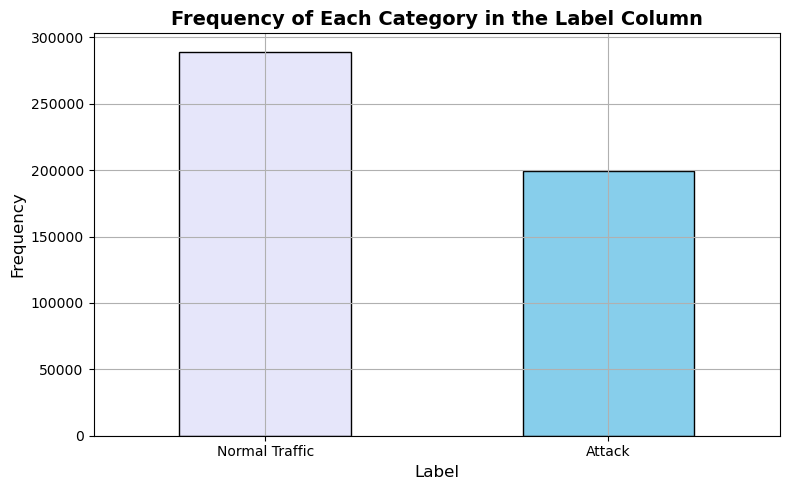

Traffic class distribution (counts):
Label
Normal Traffic    288548
Attack            199531
Name: count, dtype: int64

Traffic class distribution (percentage %):
Label
Normal Traffic    59.119118
Attack            40.880882
Name: proportion, dtype: float64


In [15]:
# Plotting bar chart showing frequency of each category in Label column
df_selected['Label'].value_counts().plot(kind='bar', color=['lavender', 'skyblue'], edgecolor='black', figsize=(8, 5))
plt.title('Frequency of Each Category in the Label Column', fontsize=14, fontweight='bold')
plt.xlabel('Label', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.grid(True)
plt.show()

# Displaying class distribution counts
print("Traffic class distribution (counts):")
print(df_selected['Label'].value_counts())

# Displaying class distribution in percentage form
print("\nTraffic class distribution (percentage %):")
print(df_selected['Label'].value_counts(normalize=True) * 100)

### 4.2 Pie Chart – Average Flow Duration and Packet Length Mean by Label

Average values by Traffic Type:

                Flow Duration  Packet Length Mean
Label                                            
Attack           8.909046e+06           85.573255
Normal Traffic   8.966348e+06           85.542480


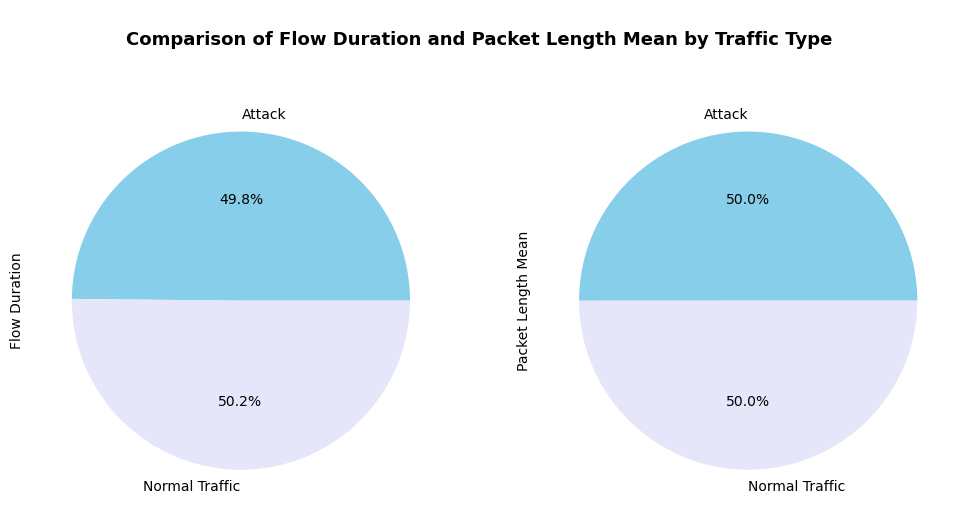

In [16]:
# Calculating averages grouped by Label using pandas groupby
average_values = df_selected.groupby('Label')[['Flow Duration', 'Packet Length Mean']].mean()

print("Average values by Traffic Type:\n")
print(average_values)

# Plotting pie charts
average_values.plot(
    kind='pie',
    subplots=True,
    figsize=(12, 6),
    autopct='%1.1f%%',
    legend=False,
    colors = ['skyblue', 'lavender']
)
plt.suptitle('\nComparison of Flow Duration and Packet Length Mean by Traffic Type', fontsize=13, fontweight='bold')
plt.show()

### 4.3 Boxplot – Fwd Packet Length Mean Grouped by Label

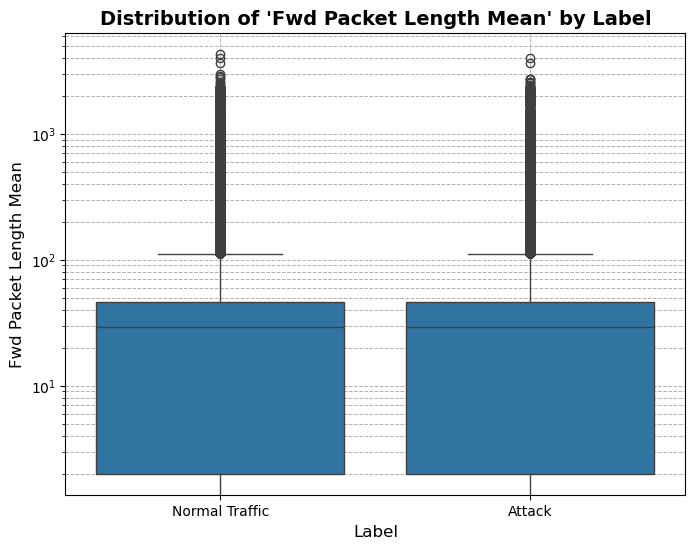


Descriptive Statistics (Fwd Packet Length Mean by Label):

                   count       mean         std  min  25%   50%   75%  \
Label                                                                   
Attack          199531.0  41.879869  120.166568  0.0  2.0  29.0  46.0   
Normal Traffic  288548.0  41.643915  118.900646  0.0  2.0  29.0  46.0   

                        max  
Label                        
Attack          3974.901099  
Normal Traffic  4317.097561  


In [17]:
# Plotting boxplot of Fwd Packet Length Mean grouped by Label
plt.figure(figsize=(8, 6))
sns.boxplot(x='Label', y='Fwd Packet Length Mean', data=df_selected)
plt.title("Distribution of 'Fwd Packet Length Mean' by Label", fontsize=14, fontweight='bold')
plt.xlabel('Label', fontsize=12)
plt.ylabel('Fwd Packet Length Mean', fontsize=12)

# Applying logarithmic scale for better visualization of spread
plt.yscale('log', base=10)

plt.grid(True, which="both", ls="--", linewidth=0.7)
plt.show()

# Printing descriptive statistics grouped by Label
print("\nDescriptive Statistics (Fwd Packet Length Mean by Label):\n")
print(df_selected.groupby('Label')['Fwd Packet Length Mean'].describe())

### 4.4 Hypothesis Test – Significant Difference in Mean Flow Duration Between Classes

In [18]:
# Hypothesis test: comparing Flow Duration between traffic classes
print("Hypothesis Test: Independent Samples T-Test")
print("""
Null Hypothesis (H0)      : There is NO significant difference in mean Flow Duration between Normal Traffic and Attack traffic.
Alternative Hypothesis (H1): There IS a significant difference in mean Flow Duration between Normal Traffic and Attack traffic.
Significance Level (alpha) : 0.05
Test Chosen               : Welch's Independent Samples T-Test
Reason                    : The two groups are independent from each other and the sample size is large enough for a t-test.
""")

# Separating data by traffic class
normal_flow = df_selected[df_selected['Label'] == 'Normal Traffic']['Flow Duration']
attack_flow = df_selected[df_selected['Label'] == 'Attack']['Flow Duration']

# Performing Welch's t-test
t_stat, p_value = stats.ttest_ind(normal_flow, attack_flow, equal_var=False)

print("T-statistic:", round(t_stat, 4))
print("P-value:", round(p_value, 6))

alpha = 0.05

# Interpreting results
print("\nInterpretation:")
if p_value < alpha:
    print("Result: REJECT the Null Hypothesis (H0).")
    print("Conclusion: There IS a statistically significant difference in mean Flow Duration between Normal Traffic and Attack classes.")
else:
    print("Result: FAIL TO REJECT the Null Hypothesis (H0).")
    print("Conclusion: There is NO statistically significant difference in mean Flow Duration between Normal Traffic and Attack classes.")

Hypothesis Test: Independent Samples T-Test

Null Hypothesis (H0)      : There is NO significant difference in mean Flow Duration between Normal Traffic and Attack traffic.
Alternative Hypothesis (H1): There IS a significant difference in mean Flow Duration between Normal Traffic and Attack traffic.
Significance Level (alpha) : 0.05
Test Chosen               : Welch's Independent Samples T-Test
Reason                    : The two groups are independent from each other and the sample size is large enough for a t-test.

T-statistic: 0.7166
P-value: 0.473601

Interpretation:
Result: FAIL TO REJECT the Null Hypothesis (H0).
Conclusion: There is NO statistically significant difference in mean Flow Duration between Normal Traffic and Attack classes.
